In [1]:
%load_ext autoreload
%autoreload 2

from subareas import Subareas
from subarea_calculations import Subarea_Calculations
from sng_bond_simulation import sng_bond_simulation
from mlt_bond_simulation import mlt_bond_simulation
from premium_class import premium_calculations

from climada.hazard import TCTracks, Centroids, TropCyclone
from climada.entity import LitPop
from climada.entity import ImpfSetTropCyclone
import numpy as np

### Set CAT Bond Basics

In [22]:
### Bond Basics ###
countries = [659, 388, 84]  # St. Kitts and Nevis, Jamaica, Belize
exhaustion_point = 0.5 # principal should be 50% of exposure 
attachment_point = 0.05 # minimum payout should be 5% of exposure
exhaustion_point_method = 'Exposure_Share' # could also be "Return_Period" or None
attachment_point_method = 'Exposure_Share' # could also be "Return_Period" or None
term = 3  # term of bond in years
num_of_terms = 20 # number of terms to simulate
par_index = 60 # statistic for parametric index (e.g. 60 for 60th percentile)

### Subarea Basics ###
resolution_st_kitts = 0.05 # resolution used to derive subareas for St. Kitts and Nevis
resolution_jamaica = 0.5 # resolution used to derive subareas for Jamaica
resolution_belize = 0.5 # resolution used to derive subareas for Belize

### Pricing Basics ###
peak_peril = 0 # indicator if bond is considered peak peril (1) or not (0)
hybrid_trigger = 0 # indicator if bond contains a hybrid trigger (1) or not (0)
investment_graded = 0 # indicator if bond is investment graded (1) or not (0)
target_sharpe = 0.5 # target Sharpe ratio for benchmark pricing 
risk_free_rate = 0.0  # risk free rate for Sharpe ratio and simulation of returns

### Define Exposure, Hazard, and Vulnerability

In [3]:
### ST. KITTS AND NEVIS ###
tr_irma = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2017242N16333"
)  # IRMA 2017
tr_irma.equal_timestep()
tr_irma.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 17.0, 17.5, -62.9, -62.5
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_irma = TropCyclone.from_tracks(tr_irma, centroids=cent)


exp_kit = LitPop.from_countries(
        [str(countries[0])], fin_mode='gdp', reference_year=2020
    )

impfset = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet()
iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp_kit.gdf.loc[exp_kit.gdf.region_id == countries[0], 'impf_TC'] = 1

# change dates of tc events to allow simulation of multiple years
tc_irma.date = np.array([736576, 736596, 736649, 736659, 736668, 736681, 736701, 736702, 736715, 736726,
 736727, 736731, 736743, 736753, 736762, 736781, 736787, 736803, 736808, 736821,
 736843, 736848, 736854, 736868, 736872, 736878, 736892, 736900, 736904, 736912,
 736921, 736926, 736940, 736945, 736952, 736963, 736976, 736983, 736993, 737003,
 737012, 737020, 737031, 737037, 737048, 737059, 737068, 737074, 737081, 737092,
 737098])

2025-11-21 15:59:53,987 - climada.hazard.tc_tracks - INFO - Progress: 100%
2025-11-21 15:59:54,049 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2025-11-21 15:59:54,110 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.


<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.


2025-11-21 16:00:00,772 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2025-11-21 16:00:00,890 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 546 coastal centroids.
2025-11-21 16:00:01,514 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2025-11-21 16:00:02,107 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2025-11-21 16:00:02,718 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2025-11-21 16:00:03,193 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2025-11-21 16:00:03,753 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2025-11-21 16:00:04,491 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 70%
2025-11-21 16:00:05,091 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 82%
2025-11-21 16:00:05,652 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 94%
2025-11-21 16

In [4]:
tr_melissa = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2025291N11319"
)  # Melissa 2025
tr_melissa.equal_timestep()
tr_melissa.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 17.5, 18.75, -78.5, -76
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_melissa = TropCyclone.from_tracks(tr_melissa, centroids=cent)


exp_jam = LitPop.from_countries(
        [str(countries[1])], fin_mode='gdp', reference_year=2020
    )

iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp_jam.gdf.loc[exp_jam.gdf.region_id == countries[1], 'impf_TC'] = 1

# change dates of tc events to allow simulation of multiple years
tc_melissa.date = np.array([736694, 736774, 736874, 736981, 737013, 737080, 737099, 737155,
       737206, 737297, 737398, 737401, 737482, 737496, 737535, 737576,
       737630, 737677, 737681, 737732, 737765, 737825, 737887, 737937,
       737990, 738024, 738086, 738175, 738278, 738297, 738334, 738390,
       738452, 738536, 738563, 738582, 738633, 738701, 738738, 738795,
       738850, 738884, 738928, 738989, 739062, 739101, 739143, 739193,
       739221, 739268, 739297])

2025-11-21 16:00:09,959 - climada.hazard.tc_tracks - INFO - Progress: 100%
2025-11-21 16:00:10,006 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2025-11-21 16:00:10,045 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.
2025-11-21 16:00:13,021 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2025-11-21 16:00:13,065 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 7938 coastal centroids.
2025-11-21 16:00:23,029 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2025-11-21 16:00:27,883 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2025-11-21 16:00:33,102 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2025-11-21 16:00:39,542 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2025-11-21 16:00:45,759 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2025-11-2

2025-11-21 16:22:41,261 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: BLZ (84)...

2025-11-21 16:22:41,814 - climada.entity.exposures.litpop.gpw_population - INFO - GPW Version v4.11
2025-11-21 16:22:41,849 - climada.entity.exposures.litpop.gpw_population - INFO - GPW Version v4.11
2025-11-21 16:22:41,891 - climada.entity.exposures.litpop.gpw_population - INFO - GPW Version v4.11
2025-11-21 16:22:41,919 - climada.entity.exposures.litpop.gpw_population - INFO - GPW Version v4.11
2025-11-21 16:22:41,949 - climada.entity.exposures.litpop.gpw_population - INFO - GPW Version v4.11
2025-11-21 16:22:41,972 - climada.entity.exposures.litpop.gpw_population - INFO - GPW Version v4.11
2025-11-21 16:22:42,023 - climada.entity.exposures.litpop.gpw_population - INFO - GPW Version v4.11
2025-11-21 16:22:42,050 - climada.entity.exposures.litpop.gpw_population - INFO - GPW Version v4.11
2025-11-21 16:22:42,071 - climada.entity.exposures.litpop.gpw_population - I

<GeoAxes: >

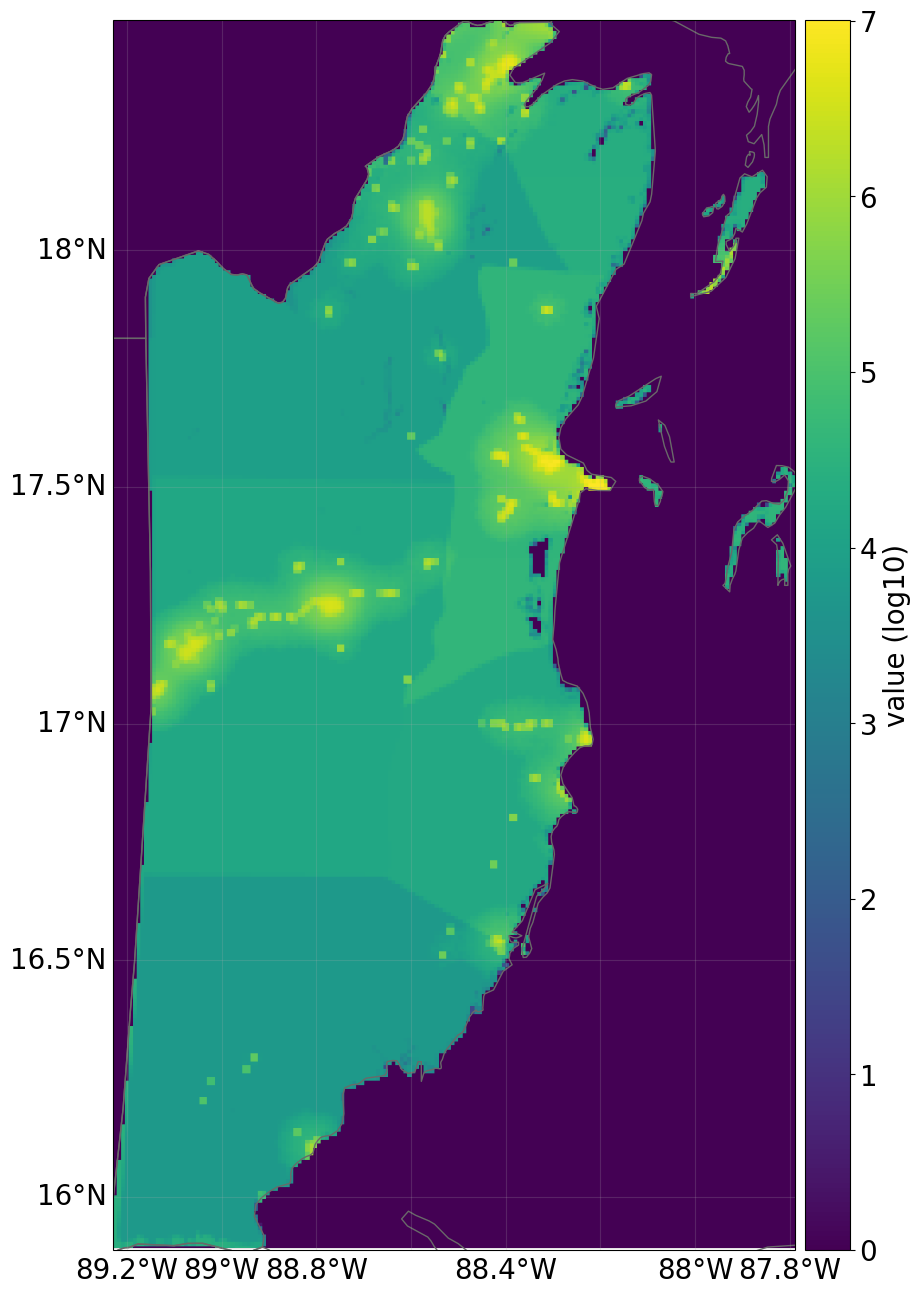

In [18]:
exp_bel = LitPop.from_countries(
        [countries[2]], fin_mode='gdp', reference_year=2020
    )
exp_bel.plot_raster()

In [19]:
tr_keith = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2000273N16277"
)  # Melissa 2025
tr_keith.equal_timestep()
tr_keith.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 15.5, 18.75, -89.5, -87.5
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_keith = TropCyclone.from_tracks(tr_keith, centroids=cent)


exp_bel = LitPop.from_countries(
        [countries[2]], fin_mode='gdp', reference_year=2020
    )

iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp_bel.gdf.loc[exp_bel.gdf.region_id == countries[2], 'impf_TC'] = 1

# change dates of tc events to allow simulation of multiple years
tc_keith.date = np.array([736694, 736774, 736874, 736981, 737013, 737080, 737099, 737155,
       737206, 737297, 737398, 737401, 737482, 737496, 737535, 737576,
       737630, 737677, 737681, 737732, 737765, 737825, 737887, 737937,
       737990, 738024, 738086, 738175, 738278, 738297, 738334, 738390,
       738452, 738536, 738563, 738582, 738633, 738701, 738738, 738795,
       738850, 738884, 738928, 738989, 739062, 739101, 739143, 739193,
       739221, 739268, 739297])

2025-11-21 16:24:16,897 - climada.hazard.tc_tracks - INFO - Progress: 100%
2025-11-21 16:24:17,170 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2025-11-21 16:24:17,246 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.
2025-11-21 16:24:20,411 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2025-11-21 16:24:20,595 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 16463 coastal centroids.
2025-11-21 16:24:36,868 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2025-11-21 16:24:48,134 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2025-11-21 16:25:01,556 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2025-11-21 16:25:14,041 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2025-11-21 16:25:24,325 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2025-11-

### Initialise Subarea Class

2025-11-21 18:36:44,599 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


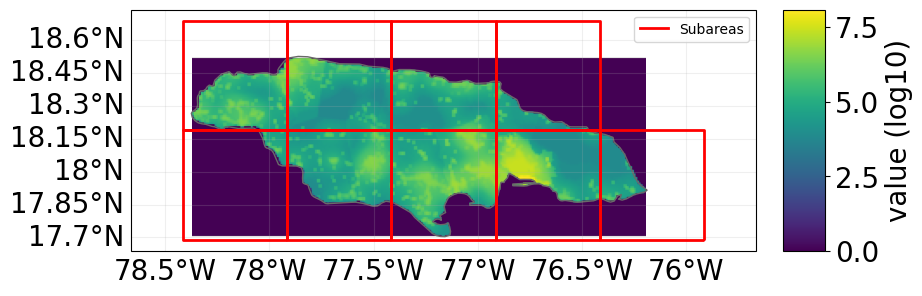

2025-11-21 18:37:08,081 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


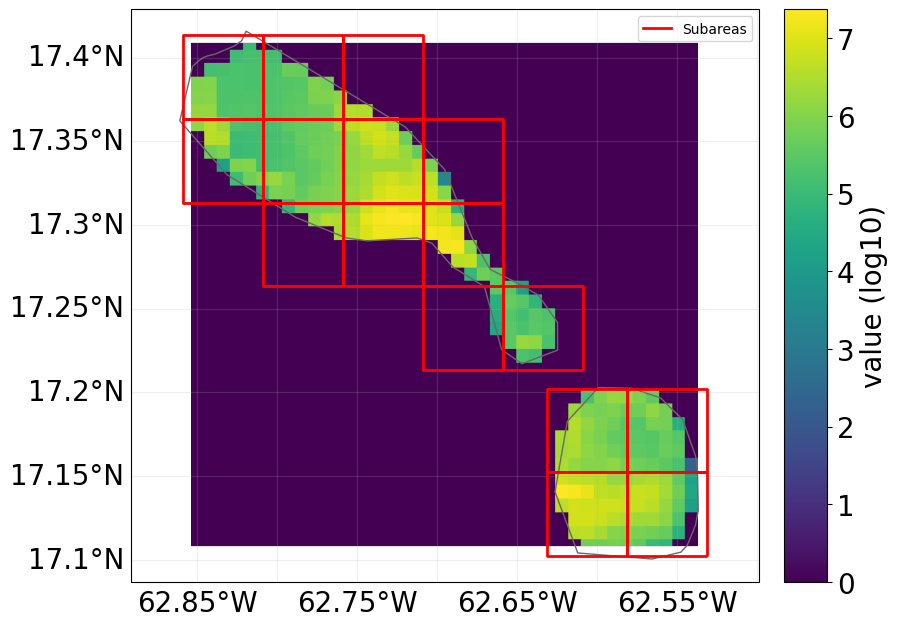

2025-11-21 18:37:23,621 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


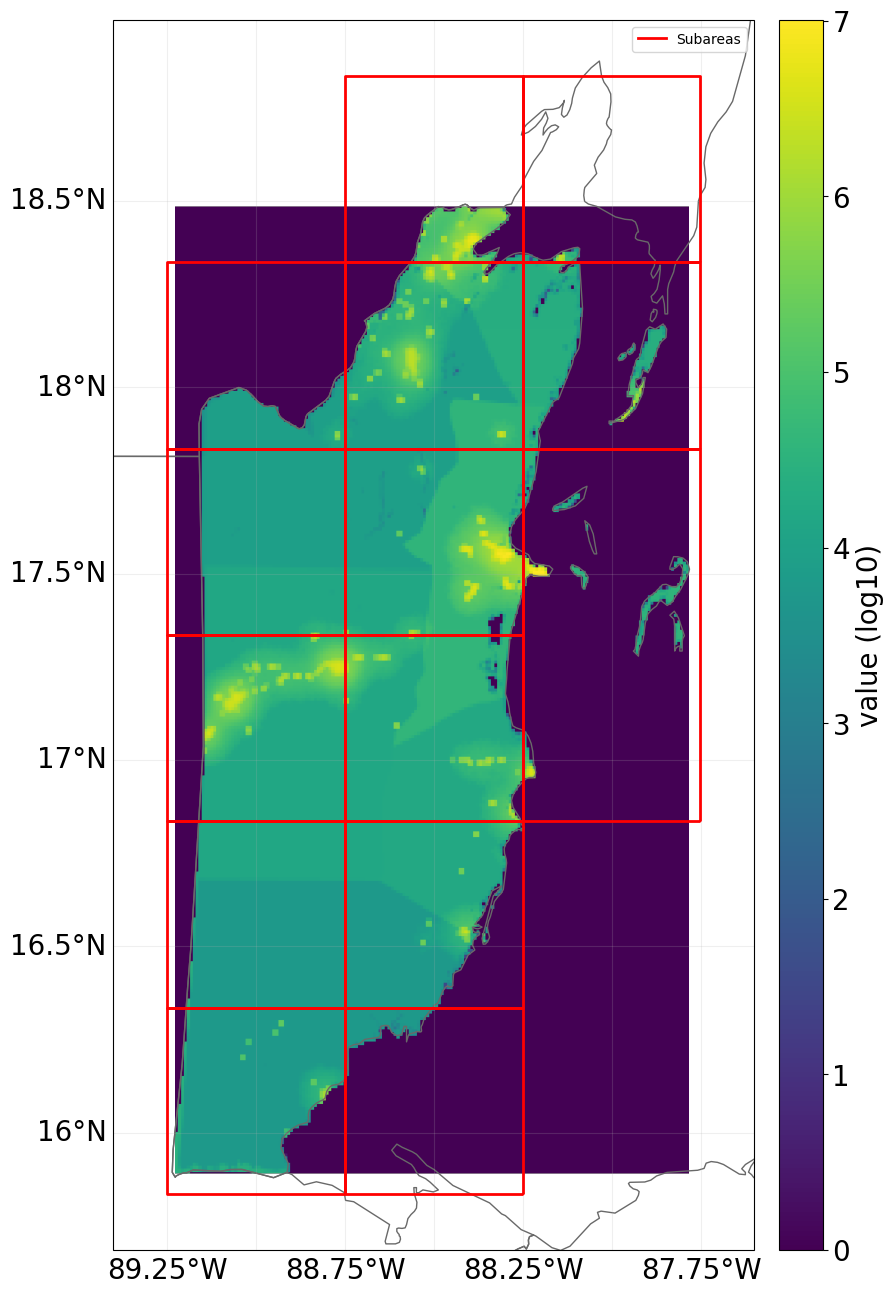

In [53]:
st_kitts_subareas = Subareas(tc_irma, impfset, exp_kit, resolution=resolution_st_kitts)
jamaica_subareas = Subareas(tc_melissa, impfset, exp_jam, resolution=resolution_jamaica)
belize_subareas = Subareas(tc_keith, impfset, exp_bel, resolution=resolution_belize)
jamaica_subareas.plot()
st_kitts_subareas.plot()
belize_subareas.plot()

### Subarea Calculations

In [54]:
st_kitts_sub_calc = Subarea_Calculations(subareas=st_kitts_subareas, index_stat=par_index)
jamaica_sub_calc = Subarea_Calculations(subareas=jamaica_subareas, index_stat=par_index)
belize_sub_calc = Subarea_Calculations(subareas=belize_subareas, index_stat=par_index)
st_kitts_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method)
jamaica_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method)
belize_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method)

2025-11-21 18:39:14,452 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for TC
2025-11-21 18:39:14,454 - climada.entity.exposures.base - INFO - Existing centroids will be overwritten for TC
2025-11-21 18:39:14,456 - climada.entity.exposures.base - INFO - Matching 328 exposures with 546 centroids.
2025-11-21 18:39:14,468 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100
2025-11-21 18:39:14,479 - climada.engine.impact_calc - INFO - Calculating impact for 984 assets (>0) and 51 events.
2025-11-21 18:39:16,808 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for TC
2025-11-21 18:39:16,809 - climada.entity.exposures.base - INFO - Existing centroids will be overwritten for TC
2025-11-21 18:39:16,810 - climada.entity.exposures.base - INFO - Matching 13552 exposures with 7938 centroids.
2025-11-21 18:39:16,859 - climada.util.coordi

### Single-Country Bond Simulation

In [7]:
### ST. KITTS AND NEVIS BOND SIMULATION ###
st_kitts_bond_sim = sng_bond_simulation(subarea_calc=st_kitts_sub_calc, term=term, number_of_terms=num_of_terms) 
st_kitts_bond_sim.init_loss_simulation()
st_kitts_premiums = premium_calculations(bond_simulation_class=st_kitts_bond_sim)
st_kitts_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
st_kitts_premiums.calc_ibrd_premium()
st_kitts_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
st_kitts_bond_sim.init_return_simulation(premium=st_kitts_premiums.chatoro_prem_rate)
display(st_kitts_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(st_kitts_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(st_kitts_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(st_kitts_premiums.ibrd_prem_rate*100,1)}")

{'EL_ann': 0.017543859649122806,
 'AP_ann': 0.023391812865497075,
 'Tot_payout': 1325883333.3333325,
 'Tot_damages': 11037139919.100546,
 'VaR_95_ann': 0.0,
 'ES_95_ann': 0.75,
 'VaR_99_ann': 0.7555314181864904,
 'ES_99_ann': 1.0}

Benchmark Sharpe Ratio premium rate: 8.7
Chatoro premium rate: 8.5
IBRD premium rate: 5.0


In [8]:
### JAMAICA BOND SIMULATION ###
jamaica_bond_sim = sng_bond_simulation(subarea_calc=jamaica_sub_calc, term=term, number_of_terms=num_of_terms) 
jamaica_bond_sim.init_loss_simulation()
jamaica_premiums = premium_calculations(bond_simulation_class=jamaica_bond_sim)
jamaica_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
jamaica_premiums.calc_ibrd_premium()
jamaica_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
jamaica_bond_sim.init_return_simulation(premium=jamaica_premiums.chatoro_prem_rate)
display(jamaica_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(jamaica_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(jamaica_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(jamaica_premiums.ibrd_prem_rate*100,1)}")

{'EL_ann': 0.02680332628076214,
 'AP_ann': 0.08771929824561403,
 'Tot_payout': 31653711605.811665,
 'Tot_damages': 50919862874.32074,
 'VaR_95_ann': 0.12926162262991353,
 'ES_95_ann': 0.4462644805505158,
 'VaR_99_ann': 0.8387774672602343,
 'ES_99_ann': 0.8543436945180888}

Benchmark Sharpe Ratio premium rate: 9.8
Chatoro premium rate: 9.8
IBRD premium rate: 6.0


In [55]:
belize_bond_sim = sng_bond_simulation(subarea_calc=belize_sub_calc, term=term, number_of_terms=num_of_terms) 
belize_bond_sim.init_loss_simulation()
belize_premiums = premium_calculations(bond_simulation_class=belize_bond_sim)
belize_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
belize_premiums.calc_ibrd_premium()
belize_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
belize_bond_sim.init_return_simulation(premium=belize_premiums.chatoro_prem_rate)
display(belize_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(belize_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(belize_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(belize_premiums.ibrd_prem_rate*100,1)}")

{'EL_ann': 0.03539315772390796,
 'AP_ann': 0.11695906432748537,
 'Tot_payout': 6181898997.912401,
 'Tot_damages': 9590299020.561695,
 'VaR_95_ann': 0.2502831832790935,
 'ES_95_ann': 0.42061594416208714,
 'VaR_99_ann': 0.5701643301269493,
 'ES_99_ann': 0.6061999788723924}

Benchmark Sharpe Ratio premium rate: 10.1
Chatoro premium rate: 11.0
IBRD premium rate: 6.9


### Multi-Country Bond Simulation

In [56]:
mlt_cat_bond = mlt_bond_simulation(subarea_calc_list=[st_kitts_sub_calc, jamaica_sub_calc, belize_sub_calc], countries_list=countries, term=term,number_of_terms=num_of_terms, tranches=[0.2,0.8])
mlt_cat_bond.init_required_principal()
mlt_cat_bond.init_loss_simulation(principal=mlt_cat_bond.requ_principal, confidence_levels=[0.95,0.99])
mlt_bond_premiums = premium_calculations(bond_simulation_class=mlt_cat_bond)
mlt_bond_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
mlt_bond_premiums.calc_ibrd_premium()
mlt_bond_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
mlt_cat_bond.init_return_simulation_tranches(premiums=[mlt_bond_premiums.chatoro_prem_rate,mlt_bond_premiums.chatoro_prem_rate])
mlt_cat_bond.init_return_simulation(premium=mlt_bond_premiums.chatoro_prem_rate)
display(mlt_cat_bond.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(mlt_bond_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(mlt_bond_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(mlt_bond_premiums.ibrd_prem_rate*100,1)}")

{'EL_ann': 0.029481977291732603,
 'AP_ann': 0.14035087719298245,
 'Payout': 39161493937.057396,
 'Damage': 71547301813.98299,
 'VaR_95_ann': 0.15776731924400075,
 'ES_95_ann': 0.43875569600979597,
 'VaR_99_ann': 0.7602314866443391,
 'ES_99_ann': 0.807913900425695}

Benchmark Sharpe Ratio premium rate: 9.8
Chatoro premium rate: 10.2
IBRD premium rate: 6.3
